# 1D Bridge Authoring


In [1]:
#!pip install --upgrade ras-commander


## Development Mode

Set `USE_LOCAL_SOURCE = True` when running from a local ras-commander checkout. The committed default uses the installed package; repository test execution can still use local source through `PYTHONPATH`.


# 1D Bridge Geometry Authoring

Author bridge deck, pier, abutment, approach-section, coefficient, and HTAB
records in a real HEC-RAS geometry file, then compute the plan, inspect
compute messages for bridge-related problems, and extract bridge results
from the HDF output.

**Scope:** This notebook covers 1D river/reach bridge structures
(`Bridge Culvert-` blocks) parsed by `GeomBridge`. For SA/2D and 2D-to-2D
bridge connections (`Conn BR:` blocks), see notebook 215.

In [2]:
# =============================================================================
# DEVELOPMENT MODE TOGGLE
# =============================================================================
USE_LOCAL_SOURCE = False

if USE_LOCAL_SOURCE:
    import sys
    from pathlib import Path

    cwd = Path.cwd()
    local_path = cwd if (cwd / "ras_commander").exists() else cwd.parent
    if str(local_path) not in sys.path:
        sys.path.insert(0, str(local_path))
    print(f"LOCAL SOURCE MODE: loading from {local_path / 'ras_commander'}")
else:
    print("PIP PACKAGE MODE: loading installed ras-commander")

from pathlib import Path
import logging
import os
import re
import time
import warnings

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from ras_commander import HdfResultsPlan, RasCmdr, RasExamples, RasPrj, init_ras_project
from ras_commander.geom import GeomBridge, GeomCrossSection, GeomCulvert
from ras_commander.results import ResultsParser

warnings.filterwarnings("ignore", category=FutureWarning)
logging.getLogger("ras_commander").setLevel(logging.CRITICAL)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

import ras_commander

print(f"Loaded: {ras_commander.__file__}")


PIP PACKAGE MODE: loading installed ras-commander


Loaded: <workspace>\ras_commander\__init__.py


## Parameters


In [3]:
PROJECT_NAME = "Example 13 - Singler Bridge (WSPRO)"
PROJECT_SUFFIX = "216_bridge_authoring"
PLAN_NUMBER = "01"
NUM_CORES = 1

RAS_EXE = Path(os.environ.get(
    "HECRAS_EXE",
    r"C:/Program Files (x86)/HEC/HEC-RAS/7.0/Ras.exe",
))

cwd = Path.cwd()
REPO_ROOT = cwd if (cwd / "ras_commander").exists() else cwd.parent
WORK_ROOT = Path(os.environ.get(
    "RAS_COMMANDER_WORKDIR",
    REPO_ROOT / "working" / "bridge_authoring",
))

if not RAS_EXE.exists():
    raise FileNotFoundError(f"HEC-RAS executable not found: {RAS_EXE}")

WORK_ROOT.mkdir(parents=True, exist_ok=True)

print(f"HEC-RAS executable: {RAS_EXE}")
print(f"Working folder: {WORK_ROOT}")


HEC-RAS executable: <hec_ras_install>
Working folder: <workspace>\working\bridge_authoring


## Helpers


In [4]:
def build_internal_approach_sections(geom_file, river, reach, rs):
    adjacent = GeomCulvert.get_adjacent_cross_sections(geom_file, river, reach, rs)
    if not adjacent["upstream"] or not adjacent["downstream"]:
        raise ValueError("Bridge must have adjacent upstream and downstream cross sections")

    frames = []
    banks = {}
    for location in ["upstream", "downstream"]:
        xs_rs = adjacent[location]["RS"]

        sta_elev = GeomCrossSection.get_station_elevation(geom_file, river, reach, xs_rs).copy()
        sta_elev.insert(0, "Location", location)
        sta_elev.insert(1, "DataType", "station_elevation")
        frames.append(sta_elev)

        mannings = GeomCrossSection.get_mannings_n(geom_file, river, reach, xs_rs).copy()
        mannings = mannings.rename(columns={"n_value": "N_Value"})[["Station", "N_Value"]]
        mannings.insert(0, "Location", location)
        mannings.insert(1, "DataType", "mannings_n")
        frames.append(mannings)

        banks[location] = list(GeomCrossSection.get_bank_stations(geom_file, river, reach, xs_rs))

    return pd.concat(frames, ignore_index=True), banks, adjacent


def bridge_related_problem_lines(messages):
    target_terms = re.compile(
        r"(bridge|deck|pier|abut|approach|htab|geometry|geom|hydraulic table)",
        re.IGNORECASE,
    )
    problem_terms = re.compile(
        r"(error|warning|failed|unable|cannot|invalid)",
        re.IGNORECASE,
    )
    return [
        line.strip()
        for line in messages.splitlines()
        if target_terms.search(line) and problem_terms.search(line)
    ]


def require_backup(path_like):
    backup_path = Path(path_like)
    if not backup_path.exists():
        raise FileNotFoundError(f"Expected backup was not created: {backup_path}")
    return backup_path


print("Helper functions ready")


Helper functions ready


## Extract And Inspect The Bridge Project


In [5]:
project_path = RasExamples.extract_project(
    PROJECT_NAME,
    output_path=WORK_ROOT,
    suffix=PROJECT_SUFFIX,
)

ras_obj = RasPrj()
init_ras_project(
    project_path,
    str(RAS_EXE),
    ras_object=ras_obj,
    load_results_summary=False,
)

plan_rows = ras_obj.plan_df[
    ras_obj.plan_df["plan_number"].astype(str).str.zfill(2).eq(PLAN_NUMBER)
]
if plan_rows.empty:
    raise ValueError(f"Plan {PLAN_NUMBER} not found")

plan_row = plan_rows.iloc[0]
geom_file = Path(plan_row["Geom Path"])
plan_path = Path(plan_row["full_path"])

bridges = GeomBridge.get_bridges(geom_file)
if bridges.empty:
    raise ValueError("No bridge structures found in the selected geometry")

bridge = bridges[bridges["NumPiers"].gt(0)].iloc[0]
river = bridge["River"]
reach = bridge["Reach"]
rs = str(bridge["RS"])

print(f"Project path: {project_path}")
print(f"Geometry file: {geom_file.name}")
print(f"Authoring target: {river} / {reach} / RS {rs}")

display(ras_obj.plan_df[["plan_number", "Plan Title", "Geom File", "Flow File", "flow_type"]])
display(bridges[["River", "Reach", "RS", "NumDecks", "NumPiers", "HasAbutment", "HTabHWMax"]])


Project path: <workspace>\working\bridge_authoring\Example 13 - Singler Bridge (WSPRO)_216_bridge_authoring
Geometry file: BOGCHIT.g01
Authoring target: Bogue Chitto / Johnston Sta / RS 52.37


,plan_number,Plan Title,Geom File,Flow File,flow_type
0,01,WSPRO Bridge Analysis,01,01,Steady


,River,Reach,RS,NumDecks,NumPiers,HasAbutment,HTabHWMax
0,Bogue Chitto,Johnston Sta,52.37,6,17,True,339.0


## Author Bridge Geometry Blocks


In [6]:
backups = {}

deck = GeomBridge.get_deck(geom_file, river, reach, rs)
deck_update = deck.copy()
deck_update.loc[deck_update["Location"].eq("upstream"), "Elevation"] += 0.10
low_chord_mask = deck_update["LowChord"].astype(float).gt(0)
deck_update.loc[low_chord_mask, "LowChord"] += 0.05
backups["deck"] = require_backup(GeomBridge.set_deck(
    geom_file,
    river,
    reach,
    rs,
    deck_update,
    distance=bridge["DeckDistance"],
    width=bridge["DeckWidth"],
    weir_coefficient=2.7,
))

piers = GeomBridge.get_piers(geom_file, river, reach, rs)
piers_update = piers.copy(deep=True)
for col in ["UpstreamWidths", "DownstreamWidths"]:
    widths = list(piers_update.at[0, col])
    piers_update.at[0, col] = [width + 0.05 for width in widths]
backups["piers"] = require_backup(GeomBridge.set_piers(geom_file, river, reach, rs, piers_update))

abutments = GeomBridge.get_abutment(geom_file, river, reach, rs)
abutments_update = abutments.copy()
abutment_mask = abutments_update["AbutmentIndex"].eq(1) & abutments_update["Location"].eq("upstream")
abutments_update.loc[abutment_mask, "Parameter"] += 0.05
backups["abutments"] = require_backup(GeomBridge.set_abutments(
    geom_file,
    river,
    reach,
    rs,
    abutments_update,
))

approach_df, approach_banks, adjacent_xs = build_internal_approach_sections(geom_file, river, reach, rs)
backups["approach"] = require_backup(GeomBridge.set_approach_sections(
    geom_file,
    river,
    reach,
    rs,
    approach_df,
    upstream_banks=approach_banks["upstream"],
    downstream_banks=approach_banks["downstream"],
))

backups["coefficients"] = require_backup(GeomBridge.set_coefficients(
    geom_file,
    river,
    reach,
    rs,
    br_coef={3: 1.30},
    wspro={4: 2},
))

htab_result = GeomBridge.set_htab(
    geom_file,
    river,
    reach,
    rs,
    hw_max=345.0,
    max_flow=60000.0,
    free_flow_points=100,
    submerged_curves=60,
    points_per_curve=50,
    validate=False,
)
backups["htab"] = require_backup(htab_result["backup_path"])

print("Created backups:")
for name, backup_path in backups.items():
    print(f"  {name}: {backup_path.name}")


Created backups:
  deck: BOGCHIT.g01.bak
  piers: BOGCHIT.g01.bak1
  abutments: BOGCHIT.g01.bak2
  approach: BOGCHIT.g01.bak3
  coefficients: BOGCHIT.g01.bak4
  htab: BOGCHIT.g01.bak5


## Round-Trip Review


,Deck Rows,Pier Rows,Abutment Rows,Approach Sta/Elev Rows,Approach Manning Rows,Approach Bank Rows,BR Coef[3],HTAB HW Max,HTAB Max Flow
0,12,17,8,238,6,2,1.3,345.0,60000.0


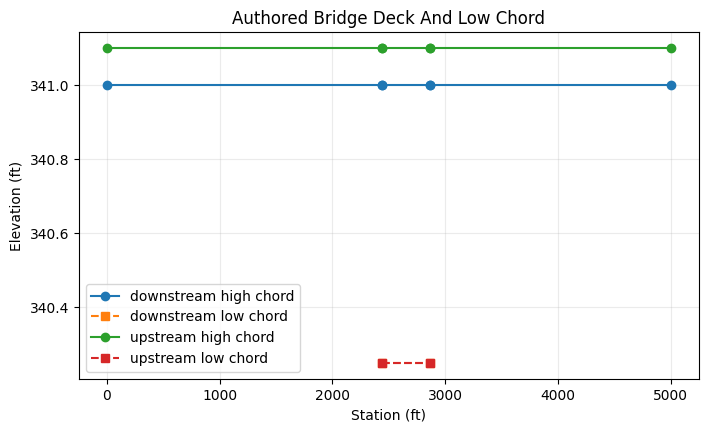

In [7]:
updated_bridge = GeomBridge.get_bridges(geom_file)
updated_bridge = updated_bridge[updated_bridge["RS"].astype(str).eq(rs)].iloc[0]
updated_deck = GeomBridge.get_deck(geom_file, river, reach, rs)
updated_piers = GeomBridge.get_piers(geom_file, river, reach, rs)
updated_abutments = GeomBridge.get_abutment(geom_file, river, reach, rs)
updated_approach = GeomBridge.get_approach_sections(geom_file, river, reach, rs)
updated_coefficients = GeomBridge.get_coefficients(geom_file, river, reach, rs)
updated_htab = GeomBridge.get_htab_dict(geom_file, river, reach, rs, include_invert=False)

approach_counts = updated_approach["DataType"].value_counts().to_dict()
assert len(updated_deck) == len(deck_update)
assert len(updated_piers) == len(piers)
assert len(updated_abutments) == len(abutments)
assert approach_counts.get("station_elevation", 0) > 0
assert approach_counts.get("mannings_n", 0) > 0
assert approach_counts.get("banks", 0) == 2
assert updated_bridge["WeirCoefficient"] == 2.7
assert updated_htab["free_flow_points"] == 100

coef_row = updated_coefficients[
    updated_coefficients["ParameterType"].eq("br_coef") & updated_coefficients["Index"].eq(3)
]
assert float(coef_row["Value"].iloc[0]) == 1.30

review = pd.DataFrame([{
    "Deck Rows": len(updated_deck),
    "Pier Rows": len(updated_piers),
    "Abutment Rows": len(updated_abutments),
    "Approach Sta/Elev Rows": approach_counts.get("station_elevation", 0),
    "Approach Manning Rows": approach_counts.get("mannings_n", 0),
    "Approach Bank Rows": approach_counts.get("banks", 0),
    "BR Coef[3]": float(coef_row["Value"].iloc[0]),
    "HTAB HW Max": updated_htab["hw_max"],
    "HTAB Max Flow": updated_htab["max_flow"],
}])
display(review)

fig, ax = plt.subplots(figsize=(8, 4.5))
for location, group in updated_deck.groupby("Location"):
    low_chord = group[group["LowChord"].astype(float).gt(0)]
    ax.plot(group["Station"], group["Elevation"], marker="o", label=f"{location} high chord")
    if not low_chord.empty:
        ax.plot(low_chord["Station"], low_chord["LowChord"], marker="s", linestyle="--", label=f"{location} low chord")
ax.set_xlabel("Station (ft)")
ax.set_ylabel("Elevation (ft)")
ax.set_title("Authored Bridge Deck And Low Chord")
ax.legend(loc="best")
ax.grid(True, alpha=0.25)
plt.show()


## Compute And Validate Messages


In [8]:
start = time.perf_counter()
compute_result = RasCmdr.compute_plan(
    PLAN_NUMBER,
    ras_object=ras_obj,
    force_geompre=True,
    force_rerun=True,
    num_cores=NUM_CORES,
    verify=True,
)
runtime_sec = time.perf_counter() - start

data_errors_path = plan_path.parent / f"{plan_path.name}.data_errors.txt"
if data_errors_path.exists():
    raise RuntimeError(data_errors_path.read_text(encoding="utf-8", errors="replace"))

if not compute_result:
    raise RuntimeError(f"HEC-RAS compute failed for plan {PLAN_NUMBER}: {compute_result!r}")

hdf_path = Path(ras_obj.plan_df.loc[
    ras_obj.plan_df["plan_number"].astype(str).str.zfill(2).eq(PLAN_NUMBER),
    "HDF_Results_Path",
].iloc[0])

messages = HdfResultsPlan.get_compute_messages(PLAN_NUMBER, ras_object=ras_obj)
parsed = ResultsParser.parse_compute_messages(messages)
bridge_problems = bridge_related_problem_lines(messages)

assert hdf_path.exists(), f"Expected result HDF was not created: {hdf_path}"
assert parsed["completed"], "Compute messages did not report Complete Process"
assert not parsed["has_errors"], parsed["first_error_line"]
assert not bridge_problems, "Bridge-related compute problems:\n" + "\n".join(bridge_problems)

validation = pd.DataFrame([{
    "Compute Result": repr(compute_result),
    "Runtime (s)": round(runtime_sec, 2),
    "Results HDF Exists": hdf_path.exists(),
    "Compute Completed": parsed["completed"],
    "Compute Error Count": parsed["error_count"],
    "Compute Warning Count": parsed["warning_count"],
    "Bridge Problem Lines": len(bridge_problems),
    "Compute Message Characters": len(messages),
}])
display(validation)

print(messages[:700])


,Compute Result,Runtime (s),Results HDF Exists,Compute Completed,Compute Error Count,Compute Warning Count,Bridge Problem Lines,Compute Message Characters
0,"ComputeResult(SUCCESS, results_df_row=available)",2.35,True,True,0,0,0,722


Plan: 'WSPRO Bridge Analysis' (BOGCHIT.p01)
Simulation started at: 11Jun2026 01:14:13 PM

Writing Plan GIS Data...
Completed Writing Plan GIS Data
Writing Geometry...
  Computing Bank Lines
  Bank lines generated in 34 ms
  Computing Edge Lines
  Edge Lines generated in 21 ms
  Computing XS Interpolation Surface
  XS Interpolation Surface generated in 49 ms
Completed Writing Geometry
Writing Event Conditions ...
Completed Writing Event Condition Data

	
Steady Flow Simulation HEC-RAS 7.0 April 2026
 

Finished Steady Flow Simulation


Computations Summary

Computation Task	Time(hh:mm:ss)
Completing Geometry, Flow and Plan	       1
Steady Flow Computations	<1
Compl


## Extract Bridge Results From HDF

The compute validation above proves HEC-RAS accepted the modified bridge
geometry. As final proof that the bridge actively participated in the
simulation, extract the bridge structure's hydraulic results from the HDF
output using `HdfStruc1D` (max HW/TW/flow) and `HdfResultsPlan.get_steady_results()`
(per-profile water surface and flow at flanking cross sections).

In [9]:
from ras_commander.hdf import HdfStruc1D

bridge_max = HdfStruc1D.get_structure_max_values(hdf_path, river, reach, rs)
print(f"HdfStruc1D.get_structure_max_values at RS {rs}:")
for key, value in bridge_max.items():
    print(f"  {key}: {value}")

assert bridge_max["found"], f"Bridge at RS {rs} not found in HDF results"

max_flow = bridge_max["max_flow"]
max_us_ws = bridge_max["max_hw"]
max_ds_ws = bridge_max["max_tw"]

steady_df = HdfResultsPlan.get_steady_results(hdf_path)
us_rs = bridge_max["hw_source"].split("/")[-1].split(" ")[0]
ds_rs = bridge_max["tw_source"].split("/")[-1].split(" ")[0]

us_results = steady_df[steady_df["node_id"] == us_rs][["profile", "node_id", "wsel", "flow", "energy"]]
ds_results = steady_df[steady_df["node_id"] == ds_rs][["profile", "node_id", "wsel", "flow", "energy"]]

bridge_results = pd.merge(
    us_results.rename(columns={"wsel": "US WS (ft)", "flow": "US Flow (cfs)", "energy": "US EG (ft)", "node_id": "US XS"}),
    ds_results.rename(columns={"wsel": "DS WS (ft)", "flow": "DS Flow (cfs)", "energy": "DS EG (ft)", "node_id": "DS XS"}),
    on="profile",
)
display(bridge_results)

print(f"\n{'='*70}")
print(f"STRUCTURE VALIDATION: Bridge at RS {rs} carried flow in simulation")
print(f"  Max flow:        {max_flow:,.1f} cfs ({bridge_max['flow_source']})")
print(f"  Max US WS:       {max_us_ws:.2f} ft ({bridge_max['hw_source']})")
print(f"  Max DS WS:       {max_ds_ws:.2f} ft ({bridge_max['tw_source']})")
print(f"  WS differential: {max_us_ws - max_ds_ws:.2f} ft")
print(f"{'='*70}")

HdfStruc1D.get_structure_max_values at RS 52.37:
  max_hw: 573.1385498046875
  max_tw: 334.4490966796875
  max_flow: 31500.0
  hw_source: Bogue Chitto/Johnston Sta/52.38 (US of 52.37)
  tw_source: Bogue Chitto/Johnston Sta/52.00 (DS of 52.37)
  flow_source: Bogue Chitto/Johnston Sta/52.38 (US of 52.37)
  found: True


,profile,US XS,US WS (ft),US Flow (cfs),US EG (ft),DS XS,DS WS (ft),DS Flow (cfs),DS EG (ft)
0,50 yr,52.38,548.656494,25000.0,NaN,52.00,333.679321,25000.0,NaN
1,100 yr,52.38,573.138550,31500.0,NaN,52.00,334.449097,31500.0,NaN



STRUCTURE VALIDATION: Bridge at RS 52.37 carried flow in simulation
  Max flow:        31,500.0 cfs (Bogue Chitto/Johnston Sta/52.38 (US of 52.37))
  Max US WS:       573.14 ft (Bogue Chitto/Johnston Sta/52.38 (US of 52.37))
  Max DS WS:       334.45 ft (Bogue Chitto/Johnston Sta/52.00 (DS of 52.37))
  WS differential: 238.69 ft


## Summary


In [10]:
summary = pd.DataFrame([{
    "Project": PROJECT_NAME,
    "Plan": PLAN_NUMBER,
    "Bridge RS": rs,
    "Backups Created": len(backups),
    "Approach Source XS": f"US {adjacent_xs['upstream']['RS']} / DS {adjacent_xs['downstream']['RS']}",
    "HEC-RAS Compute Success": bool(compute_result),
    "Bridge Compute Problems": len(bridge_problems),
    "Max Flow (cfs)": f"{max_flow:,.1f}",
    "US WS (ft)": f"{max_us_ws:.2f}",
    "DS WS (ft)": f"{max_ds_ws:.2f}",
}])
display(summary)
print("1D bridge authoring workflow complete: geometry authored, compute validated, results extracted.")

,Project,Plan,Bridge RS,Backups Created,Approach Source XS,HEC-RAS Compute Success,Bridge Compute Problems,Max Flow (cfs),US WS (ft),DS WS (ft)
0,Example 13 - Singler Bridge (WSPRO),01,52.37,6,US 52.38 / DS 52.36,True,0,"31,500.0",573.14,334.45


1D bridge authoring workflow complete: geometry authored, compute validated, results extracted.
